In [1]:
import pandas as pd
df = pd.read_csv('/Salary_Dataset_DataScienceLovers.csv')
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [4]:
import pandas as pd
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [6]:
df.isnull().sum()

,0
Rating,0
Company Name,1
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [7]:
df['Company Name'].fillna(df['Company Name'].mode()[0], inplace=True)
df.isnull().sum()

/tmp/ipykernel_13470/965383814.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Company Name'].fillna(df['Company Name'].mode()[0], inplace=True)


,0
Rating,0
Company Name,0
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [11]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (object type)
categorical_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("DataFrame after Label Encoding:")
display(df.head())

DataFrame after Label Encoding:


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,8129,28,400000,3,0,1,0
1,4.5,417,28,400000,3,0,1,0
2,4.0,9777,28,1000000,3,0,1,0
3,3.8,8533,28,300000,3,0,1,0
4,4.4,884,28,600000,3,0,1,0


In [12]:
# Separate independent and dependent variables
X = df.drop('Salary', axis=1)
y = df['Salary']

print("Independent variables (X) head:")
display(X.head())

print("\nDependent variable (y) head:")
display(y.head())

Independent variables (X) head:


,Rating,Company Name,Job Title,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,8129,28,3,0,1,0
1,4.5,417,28,3,0,1,0
2,4.0,9777,28,3,0,1,0
3,3.8,8533,28,3,0,1,0
4,4.4,884,28,3,0,1,0



Dependent variable (y) head:


,Salary
0,400000
1,400000
2,1000000
3,300000
4,600000


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (18216, 7)
Shape of X_test: (4554, 7)
Shape of y_train: (18216,)
Shape of y_test: (4554,)


## Train and Evaluate Models

### 1. Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = linear_reg_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Mean Squared Error: {mse_lr:.2f}")
print(f"Linear Regression R-squared: {r2_lr:.2f}")

Linear Regression Mean Squared Error: 386545874783.28
Linear Regression R-squared: 0.05


### 2. Decision Tree Regressor

In [15]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the model
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Mean Squared Error: {mse_dt:.2f}")
print(f"Decision Tree R-squared: {r2_dt:.2f}")

Decision Tree Mean Squared Error: 2484415021401.04
Decision Tree R-squared: -5.13


### 3. Random Forest Regressor

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest R-squared: {r2_rf:.2f}")

Random Forest Mean Squared Error: 623993827858.30
Random Forest R-squared: -0.54


### 4. Support Vector Machine (SVM) Regressor

In [17]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVMs are sensitive to feature scaling, so we'll scale the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# Initialize and train the model
svm_model = SVR(kernel='rbf') # Using RBF kernel as a common choice
svm_model.fit(X_train_scaled, y_train_scaled.ravel())

# Make predictions and inverse transform
y_pred_svm_scaled = svm_model.predict(X_test_scaled)
y_pred_svm = scaler_y.inverse_transform(y_pred_svm_scaled.reshape(-1, 1))

# Evaluate the model
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print(f"SVM Mean Squared Error: {mse_svm:.2f}")
print(f"SVM R-squared: {r2_svm:.2f}")

SVM Mean Squared Error: 374952405759.05
SVM R-squared: 0.08


### 5. K-Nearest Neighbors (KNN) Regressor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [18]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize and train the model
knn_model = KNeighborsRegressor(n_neighbors=5) # Using 5 neighbors as a starting point
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"KNN Mean Squared Error: {mse_knn:.2f}")
print(f"KNN R-squared: {r2_knn:.2f}")

KNN Mean Squared Error: 620584848289.41
KNN R-squared: -0.53


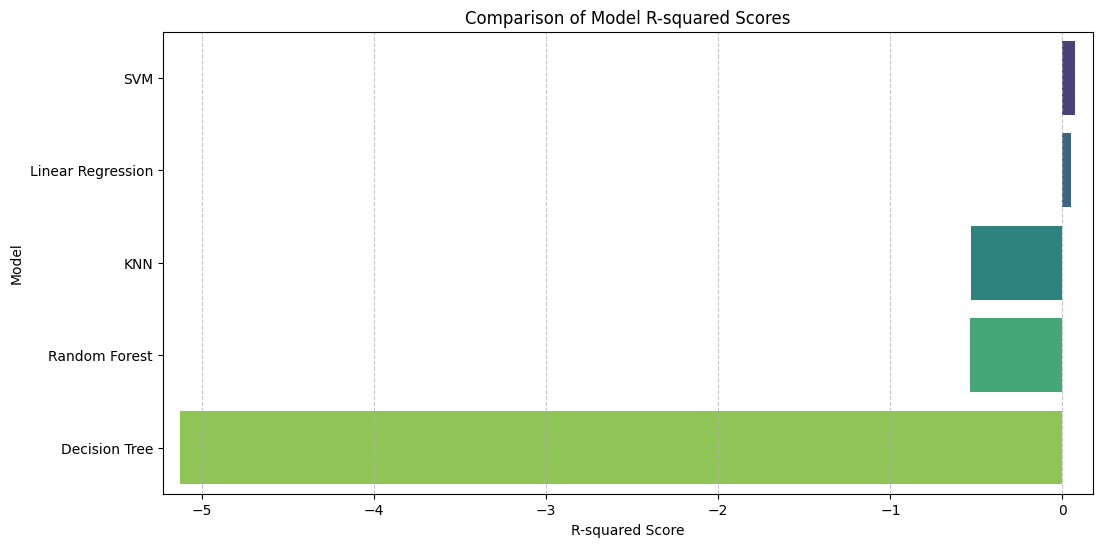

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame to store model performance metrics
model_performance = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN'],
    'R-squared': [r2_lr, r2_dt, r2_rf, r2_svm, r2_knn]
})

# Sort by R-squared for better visualization
model_performance = model_performance.sort_values(by='R-squared', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='R-squared', y='Model', hue='Model', data=model_performance, palette='viridis', legend=False)
plt.title('Comparison of Model R-squared Scores')
plt.xlabel('R-squared Score')
plt.ylabel('Model')
plt.xlim(model_performance['R-squared'].min() - 0.1, model_performance['R-squared'].max() + 0.1) # Adjust x-axis limits for clarity
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

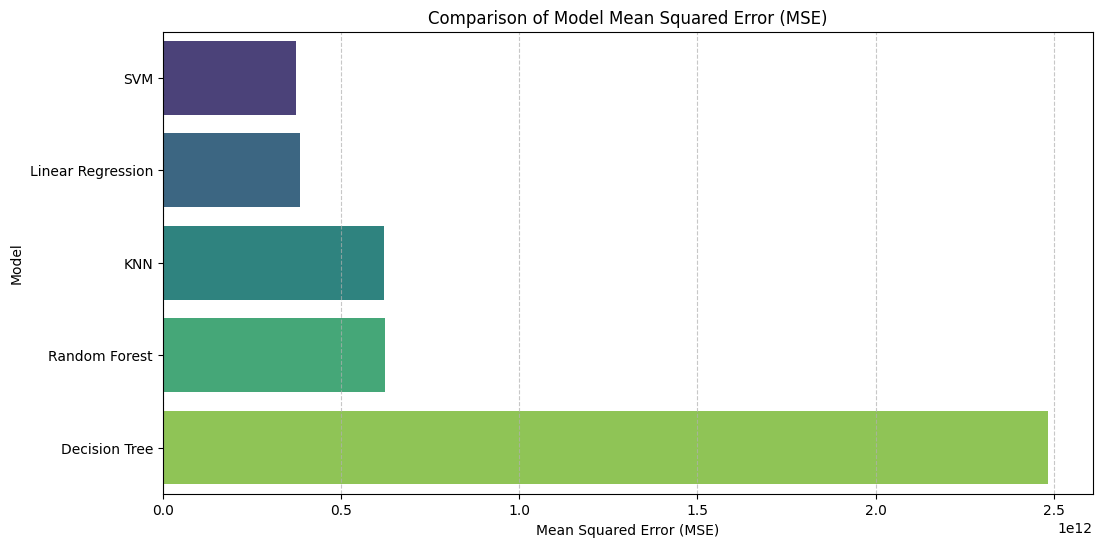

In [21]:
# Create a DataFrame to store model performance metrics for MSE
mse_performance = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN'],
    'MSE': [mse_lr, mse_dt, mse_rf, mse_svm, mse_knn]
})

# Sort by MSE for better visualization (lower is better)
mse_performance = mse_performance.sort_values(by='MSE', ascending=True)

# Create the bar plot for MSE
plt.figure(figsize=(12, 6))
sns.barplot(x='MSE', y='Model', hue='Model', data=mse_performance, palette='viridis', legend=False)
plt.title('Comparison of Model Mean Squared Error (MSE)')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Model Comparison Summary

From the evaluation metrics (R-squared and Mean Squared Error):

*   **SVM (Support Vector Machine)** appears to be the best performing model among those tested, exhibiting the highest R-squared score (0.08) and the lowest Mean Squared Error (approximately 3.75e+11). Although the R-squared is still very low, it indicates a slightly better fit compared to other models.

*   **Linear Regression** shows the second-best performance with an R-squared of 0.05 and an MSE of approximately 3.87e+11. Similar to SVM, the R-squared value is low, suggesting that a simple linear relationship might not fully capture the complexity of the data.

*   **K-Nearest Neighbors (KNN)**, **Random Forest Regressor**, and **Decision Tree Regressor** all performed poorly, indicated by their high Mean Squared Error values and negative R-squared scores. Negative R-squared values suggest that these models perform worse than simply predicting the mean of the target variable. This could be due to several factors, including the nature of the data, lack of feature engineering, or suboptimal hyperparameters.

**Conclusion:**

While SVM and Linear Regression showed marginally better performance than the other models, all models struggled to explain the variance in the 'Salary' feature, as indicated by the very low and negative R-squared values. This suggests that the current features or models might not be sufficient to accurately predict salaries in this dataset. Further feature engineering, exploration of more complex models, or hyperparameter tuning might be necessary to improve performance.

In [22]:
import pickle

# Define the filename for the saved model
model_filename = 'best_svm_model.pkl'

# Save the SVM model to the file
with open(model_filename, 'wb') as file:
    pickle.dump(svm_model, file)

print(f"Best model (SVM) saved as '{model_filename}'")

Best model (SVM) saved as 'best_svm_model.pkl'


In [23]:
from google.colab import files

files.download('best_svm_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>